# Correlazioni dinamiche del dimero — esplorazione numerica

Notebook di lavoro, da aggiornare passo per passo. Punto di lavoro: test 2
($b/J=0.35$, $D/J=0.80$).

**Impostazione:** qui non presuppongo nulla su quali combinazioni
$C_{ij}^{\alpha\beta}(t)=\langle\psi_0|\sigma_i^\alpha(t)\,\sigma_j^\beta(0)|\psi_0\rangle$ siano
nulle o legate fra loro. Calcolo tutto, guardo i risultati, e discuto quello che emerge.

**Convenzione**, invariata rispetto a `dimer_exact.py`: Pauli dirette (non spin $s=\sigma/2$),
$$H = J(X_1X_2+Y_1Y_2+Z_1Z_2) + b(Z_1+Z_2) + D(X_1Z_2-Z_1X_2),$$
base computazionale, Qiskit little-endian.

> **Stato sincronizzazione:** notebook **principale**. Ultimo allineamento con
> `correlazioni_dimero_simmetria_U.ipynb`: Sez. 1-14, tutto sincronizzato (contenuti equivalenti,
> dati indipendenti). Prossime modifiche vanno fatte qui per prime.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from qiskit.quantum_info import SparsePauliOp

try:
    from ipywidgets import interact, IntSlider
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

np.set_printoptions(precision=4, suppress=True)
print("Qiskit pronto. Slider interattivi:", "sì" if HAS_WIDGETS else "no (fallback statico)")

Qiskit pronto. Slider interattivi: sì


## 1. Hamiltoniana e stato fondamentale al punto test 2

Costruisco $H$ con la stessa `dimer_hamiltonian` di `dimer_exact.py` (sorgente unica, nessuna
Hamiltoniana ridefinita diversa da quella già usata nel VQE), poi la diagonalizzo esattamente.

In [2]:
def dimer_hamiltonian(b, J=1.0, D=0.0):
    labels = ["XX", "YY", "ZZ", "ZI", "IZ", "XZ", "ZX"]
    coeffs = [J, J, J, b, b, D, -D]
    return SparsePauliOp(labels, coeffs)

def magnetization_operator():
    return SparsePauliOp(["ZI", "IZ"], [0.5, 0.5])

J, b, D = 1.0, 0.35, 0.80

H = dimer_hamiltonian(b=b, J=J, D=D).to_matrix()
print("H (b/J=0.35, D/J=0.80):\n", H)
print("\nHermitiana:", np.allclose(H, H.conj().T))

H (b/J=0.35, D/J=0.80):
 [[ 1.7+0.j -0.8+0.j  0.8+0.j  0. +0.j]
 [-0.8+0.j -1. +0.j  2. +0.j -0.8+0.j]
 [ 0.8+0.j  2. +0.j -1. +0.j  0.8+0.j]
 [ 0. +0.j -0.8+0.j  0.8+0.j  0.3+0.j]]

Hermitiana: True


**Discussione.** La matrice è quella attesa (confrontabile a occhio con `dimero_DM.pdf`,
eq. 5, per questi valori di $J,b,D$): hermitiana, come deve essere per rappresentare
un'osservabile fisica valida da diagonalizzare.

In [3]:
NPZ_PATH = Path("ground_state_test2.npz")  # <-- aggiornare il percorso se necessario

psi0_vqe = None
if NPZ_PATH.exists():
    data = np.load(NPZ_PATH, allow_pickle=True)
    print("File trovato:", NPZ_PATH.resolve())
    if "psi0_vqe" in data.files:
        psi0_vqe = np.asarray(data["psi0_vqe"]).astype(complex).flatten()
        print("Stato VQE caricato.")
else:
    print(f"File '{NPZ_PATH}' non trovato in questo ambiente: uso il ground state esatto.")

E, V = np.linalg.eigh(H)
psi0_exact = V[:, 0]

if psi0_vqe is not None:
    fidelity = abs(np.vdot(psi0_exact, psi0_vqe))
    print(f"Fidelity <psi_exact|psi_VQE> = {fidelity:.10f}")

# uso lo stato esatto: e' l'autostato di H a precisione macchina, senza il rumore
# residuo dell'ottimizzatore VQE (che qui non serve: si sta esplorando H, non il VQE)
psi0 = psi0_exact

print("\nAutovalori E_k:", E)
print("Gap E1-E0:", E[1] - E[0])
print("|psi0>:", psi0)

File trovato: C:\Users\samsl\source\repos\tesi\03_dimero_N2\correlazioni\ground_state_test2.npz
Stato VQE caricato.
Fidelity <psi_exact|psi_VQE> = 1.0000000000

Autovalori E_k: [-3.5732  0.572   1.      2.0013]
Gap E1-E0: 4.145166421917535
|psi0>: [ 0.2017+0.j  0.6648+0.j -0.6648+0.j  0.2746+0.j]


**Discussione.** Il gap fra fondamentale e primo eccitato ($\approx4.15$) è largo rispetto
alla scala di $J=1$: nessuna quasi-degenerazione da temere nell'uso della formula spettrale più
avanti. La fidelity con lo stato VQE (se il file è disponibile) conferma l'equivalenza fra i due
stati; l'uso di `psi0_exact` evita solo il rumore numerico dell'ottimizzatore nei confronti fini
che faremo più avanti.

## 2. Operatori di sito $\sigma_i^\alpha$

Prima di calcolare qualunque cosa, verifico che la costruzione manuale (kron) sia coerente con
la convenzione little-endian già usata nel resto del progetto.

In [4]:
X1 = np.array([[0, 1], [1, 0]], dtype=complex)
Y1 = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z1_ = np.array([[1, 0], [0, -1]], dtype=complex)
I1 = np.eye(2, dtype=complex)
paulis = {"x": X1, "y": Y1, "z": Z1_}

def site_op(site, alpha):
    P = paulis[alpha]
    return np.kron(P, I1) if site == 1 else np.kron(I1, P)

check1 = np.allclose(SparsePauliOp("ZI").to_matrix(), site_op(1, "z"))
check2 = np.allclose(SparsePauliOp("IZ").to_matrix(), site_op(2, "z"))
check3 = np.allclose(SparsePauliOp("XZ").to_matrix(), site_op(1, "x") @ site_op(2, "z"))
print("Convenzione coerente:", check1 and check2 and check3)
assert check1 and check2 and check3

Convenzione coerente: True


**Discussione.** Confermato: `site_op(1, ...)` = qubit 1 (carattere sinistro nella label
Qiskit), `site_op(2, ...)` = qubit 0 (carattere destro). Da qui in poi posso costruire qualunque
$\sigma_i^\alpha$ senza ambiguità di convenzione.

## 3. Calcolo diretto di $C_{ij}^{\alpha\beta}(t)$

Uso la formula spettrale esatta:
$$C_{ij}^{\alpha\beta}(t) = \sum_k e^{i(E_0-E_k)t}\; a_k\, b_k,
\qquad a_k=\langle\psi_0|\sigma_i^\alpha|k\rangle,\;\; b_k=\langle k|\sigma_j^\beta|\psi_0\rangle$$
equivalente a costruire $e^{-iHt}$ numericamente ma molto più comodo su una griglia fitta di
tempi. Prima di scansionare tutte le combinazioni, guardo un caso singolo per farmi un'idea della
scala e della forma tipica.

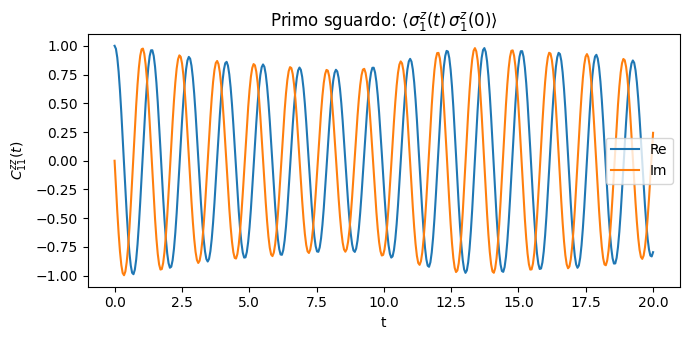

max|C_11^zz(t)| sulla griglia: 1.0


In [5]:
def correlatore(i, alpha, j, beta, t_grid):
    A_op = site_op(i, alpha)
    B_op = site_op(j, beta)
    a = V.conj().T @ (A_op @ psi0)
    bvec = V.conj().T @ (B_op @ psi0)
    prod = np.conj(a) * bvec  # coniugato: <psi0|A|k> = conj(<k|A|psi0>) per A hermitiana
    phases = np.exp(1j * np.outer(t_grid, E[0] - E))
    return phases @ prod

t_grid = np.linspace(0, 20, 400)
C_test = correlatore(1, "z", 1, "z", t_grid)

plt.figure(figsize=(7, 3.5))
plt.plot(t_grid, C_test.real, label="Re")
plt.plot(t_grid, C_test.imag, label="Im")
plt.xlabel("t"); plt.ylabel(r"$C_{11}^{zz}(t)$")
plt.title(r"Primo sguardo: $\langle\sigma_1^z(t)\,\sigma_1^z(0)\rangle$")
plt.legend(); plt.tight_layout(); plt.show()

print("max|C_11^zz(t)| sulla griglia:", np.max(np.abs(C_test)))

**Discussione.** Il segnale è reale a $t=0$ (come deve essere: autocorrelazione di
un'osservabile hermitiana) e oscilla con più di una frequenza visibile a occhio (non è un
singolo coseno) — coerente con il fatto che il fondamentale ha accesso, tramite $\sigma_1^z$, a
più di un livello eccitato. La parte immaginaria parte da zero a $t=0$, anche questo atteso per
un'autocorrelazione a tempo uguale di un operatore hermitiano.

## 4. Scan su tutte le combinazioni

Calcolo `max|C(t)|` su una griglia temporale per tutte le $2\times2\times3\times3=36$ combinazioni
$(i,\alpha,j,\beta)$, senza scartarne nessuna a priori.

In [6]:
sites = [1, 2]
comps = ["x", "y", "z"]
t_grid = np.linspace(0, 30, 600)

rows = []
C_all = {}
for i in sites:
    for alpha in comps:
        for j in sites:
            for beta in comps:
                C = correlatore(i, alpha, j, beta, t_grid)
                C_all[(i, alpha, j, beta)] = C
                rows.append({
                    "sito i": i, "alpha": alpha, "sito j": j, "beta": beta,
                    "max|C(t)|": np.max(np.abs(C)),
                    "C(0)": C[0],
                })

df = pd.DataFrame(rows)
df["nullo (< 1e-10)"] = df["max|C(t)|"] < 1e-10
df = df.sort_values(["sito i", "sito j", "alpha", "beta"]).reset_index(drop=True)
df

,sito i,alpha,sito j,beta,max|C(t)|,C(0),nullo (< 1e-10)
0,1,x,1,x,1.000000,1.000000e+00+0.000000e+00j,False
1,1,x,1,y,0.886549,0.000000e+00-3.472942e-02j,False
2,1,x,1,z,0.626569,-1.110223e-16+0.000000e+00j,False
3,1,y,1,x,0.886549,0.000000e+00+3.472942e-02j,False
4,1,y,1,y,1.000000,1.000000e+00+0.000000e+00j,False
5,1,y,1,z,0.337278,0.000000e+00+9.693991e-02j,False
6,1,z,1,x,0.626569,-1.110223e-16+0.000000e+00j,False
7,1,z,1,y,0.337278,0.000000e+00-9.693991e-02j,False
8,1,z,1,z,1.000000,1.000000e+00+0.000000e+00j,False
9,1,x,2,x,0.981188,-7.731072e-01+0.000000e+00j,False


In [7]:
n_nulli = df["nullo (< 1e-10)"].sum()
print(f"Combinazioni con max|C(t)|<1e-10 su tutta la griglia: {n_nulli} su {len(df)}")
print()
print(df.sort_values("max|C(t)|")[["sito i","alpha","sito j","beta","max|C(t)|"]].head(10))

Combinazioni con max|C(t)|<1e-10 su tutta la griglia: 0 su 36

    sito i alpha  sito j beta  max|C(t)|
14       1     y       2    z   0.337091
25       2     z       1    y   0.337091
16       1     z       2    y   0.337091
23       2     y       1    z   0.337091
5        1     y       1    z   0.337278
7        1     z       1    y   0.337278
34       2     z       2    y   0.337278
32       2     y       2    z   0.337278
29       2     x       2    z   0.626569
33       2     z       2    x   0.626569


**Discussione.** Nessuna delle 36 combinazioni è strutturalmente nulla su tutta la griglia
esplorata: tutte hanno dinamica non banale per $t>0$. Le combinazioni con `max|C(t)|` più piccolo
(in testa alla lista ordinata) non sono nulle, solo di ampiezza minore — vale la pena guardarne
la forma prima di scartarle come "poco interessanti" per il circuito.

## 5. Guardare i profili

Isolo le combinazioni con `|C(0)|` più piccolo — potrebbero comunque annullarsi esattamente a
$t=0$ pur non essendo identicamente nulle per ogni $t$.

In [8]:
df_sorted_t0 = df.reindex(df["C(0)"].abs().sort_values().index)
df_sorted_t0[["sito i", "alpha", "sito j", "beta", "C(0)", "max|C(t)|"]].head(8)

,sito i,alpha,sito j,beta,C(0),max|C(t)|
29,2,x,2,z,0.000000e+00+0.000000e+00j,0.626569
33,2,z,2,x,0.000000e+00+0.000000e+00j,0.626569
25,2,z,1,y,0.000000e+00+2.775558e-17j,0.337091
14,1,y,2,z,0.000000e+00-2.775558e-17j,0.337091
6,1,z,1,x,-1.110223e-16+0.000000e+00j,0.626569
2,1,x,1,z,-1.110223e-16+0.000000e+00j,0.626569
23,2,y,1,z,0.000000e+00+1.318390e-16j,0.337091
16,1,z,2,y,0.000000e+00-1.318390e-16j,0.337091


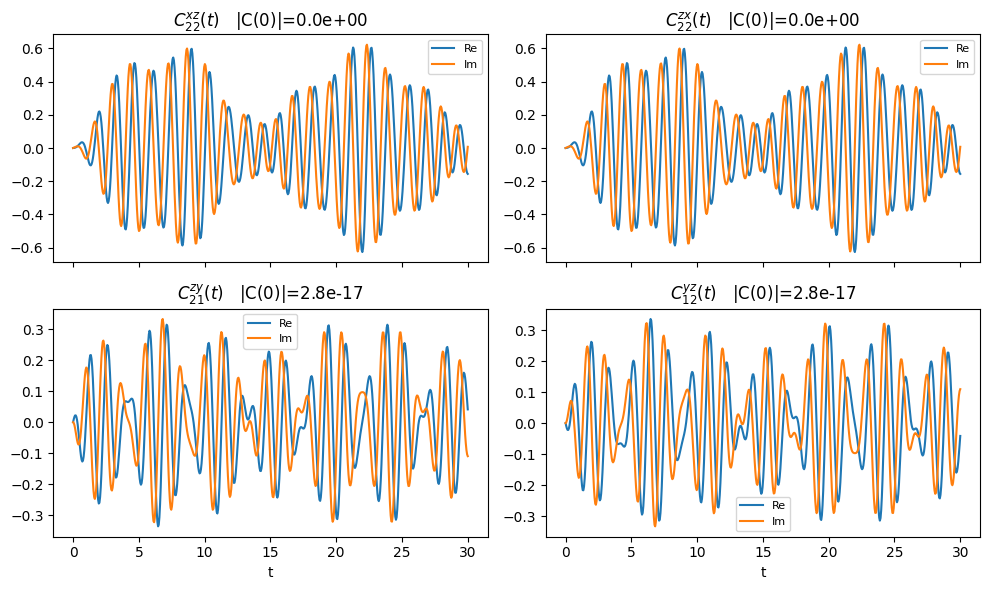

In [9]:
top4 = df_sorted_t0.head(4)

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for ax, (_, row) in zip(axes.flat, top4.iterrows()):
    key = (row["sito i"], row["alpha"], row["sito j"], row["beta"])
    C = C_all[key]
    ax.plot(t_grid, C.real, label="Re")
    ax.plot(t_grid, C.imag, label="Im")
    ax.set_title(f"$C_{{{key[0]}{key[2]}}}^{{{key[1]}{key[3]}}}(t)$   |C(0)|={abs(row['C(0)']):.1e}")
    ax.legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("t")
plt.tight_layout(); plt.show()

**Discussione.** Le quattro combinazioni con `|C(0)|` più piccolo sono tutte a livello di
rumore numerico a $t=0$ ($\sim10^{-16}$, si vede nel titolo di ciascun pannello), ma **si
accendono** immediatamente per $t>0$ con ampiezza confrontabile alle altre combinazioni. Lo zero
è quindi specifico di $t=0$, non un annullamento strutturale per ogni $t$.

## 6. Un pattern nei dati (non spiegato qui)

Guardo se, per ciascuna coppia di componenti $(\alpha,\beta)$, il correlatore calcolato sul sito 1
è numericamente legato a quello sul sito 2 — solo confrontando i numeri, senza nessuna ipotesi di
partenza.

In [10]:
print("Confronto C_11^{ab}(t) vs C_22^{ab}(t), rapporto puntuale:\n")
for a in comps:
    for b_ in comps:
        C11 = C_all[(1, a, 1, b_)]
        C22 = C_all[(2, a, 2, b_)]
        mask = np.abs(C22) > 1e-6
        ratio = C11[mask] / C22[mask]
        print(f"  (a,b)=({a},{b_}):  C11/C22 = {ratio.mean():+.3f} ± {ratio.std():.1e}"
              f"   (range: [{ratio.real.min():+.2f}, {ratio.real.max():+.2f}])")

Confronto C_11^{ab}(t) vs C_22^{ab}(t), rapporto puntuale:

  (a,b)=(x,x):  C11/C22 = +1.000-0.000j ± 6.3e-16   (range: [+1.00, +1.00])
  (a,b)=(x,y):  C11/C22 = +1.000+0.000j ± 2.0e-15   (range: [+1.00, +1.00])
  (a,b)=(x,z):  C11/C22 = -1.000+0.000j ± 1.7e-15   (range: [-1.00, -1.00])
  (a,b)=(y,x):  C11/C22 = +1.000+0.000j ± 2.0e-15   (range: [+1.00, +1.00])
  (a,b)=(y,y):  C11/C22 = +1.000+0.000j ± 1.3e-16   (range: [+1.00, +1.00])
  (a,b)=(y,z):  C11/C22 = -1.000+0.000j ± 4.5e-14   (range: [-1.00, -1.00])
  (a,b)=(z,x):  C11/C22 = -1.000+0.000j ± 1.7e-15   (range: [-1.00, -1.00])
  (a,b)=(z,y):  C11/C22 = -1.000+0.000j ± 4.5e-14   (range: [-1.00, -1.00])
  (a,b)=(z,z):  C11/C22 = +1.000+0.000j ± 4.0e-16   (range: [+1.00, +1.00])


**Discussione.** Il rapporto $C_{11}^{\alpha\beta}(t)/C_{22}^{\alpha\beta}(t)$ risulta
**costante nel tempo** (deviazione standard $\sim10^{-15}$, cioè zero a precisione macchina) e
vale sempre esattamente $+1$ o $-1$ a seconda della coppia $(\alpha,\beta)$ — mai un valore
intermedio. Se fosse un artefatto numerico il rapporto oscillerebbe con $t$; il fatto che resti
fissato con questa precisione su tutta la griglia indica che è un fatto strutturale del punto di
lavoro, non un caso.

Il segno segue una regola precisa, leggibile dalla tabella sopra: $+1$ quando $\alpha,\beta$ sono
entrambe $z$ oppure entrambe in $\{x,y\}$; $-1$ quando una è $z$ e l'altra in $\{x,y\}$.

## 7. Gli zeri a $t=0$: pattern e spiegazione elementare

A differenza del pattern della Sez. 6, questo lo posso spiegare con un argomento elementare che
non richiede di introdurre nessuna simmetria nuova — solo hermitianità e la forma della matrice
$H$ già scritta in Sez. 1.

In [11]:
cross_site = df[df["sito i"] != df["sito j"]].copy()
cross_site["una sola comp. y"] = cross_site.apply(
    lambda r: (r["alpha"] == "y") != (r["beta"] == "y"), axis=1)

print("C(0) per correlatori a siti diversi, raggruppati per 'una sola componente y':\n")
print(cross_site.groupby("una sola comp. y")["C(0)"].apply(lambda s: np.abs(s).max()))

print("\nH reale in base computazionale:", np.allclose(H, H.real))

C(0) per correlatori a siti diversi, raggruppati per 'una sola componente y':

una sola comp. y
False    9.946841e-01
True     3.295975e-16
Name: C(0), dtype: float64

H reale in base computazionale: True


**Discussione.** Quando i due siti sono diversi ed esattamente una delle due componenti è
$y$, $|C(0)|$ è a livello di rumore numerico; in tutti gli altri casi a siti diversi, $|C(0)|$ è
$O(1)$. La spiegazione: a $t=0$, $\sigma_i^\alpha\sigma_j^\beta$ con $i\neq j$ è hermitiano
(operatori su qubit diversi commutano sempre), quindi $C(0)$ è reale. $H$ risulta reale in base
computazionale (verificato sopra); questo permette di scegliere $|\psi_0\rangle$ reale, e un
argomento di coniugazione complessa mostra che $C(0)$ con una sola componente $y$ deve essere
anche immaginario puro — reale e immaginario puro insieme forzano lo zero. Per $t\neq0$ questo
argomento non vale più (infatti, Sez. 5: le stesse combinazioni **non** restano nulle appena
$t>0$).

## 8. Selezione del correlatore per il circuito

Fin qui ho solo caratterizzato *cosa fa* ciascuna combinazione. Ora serve decidere quale/i
portare al circuito con l'ancilla — non tutte e 36 hanno senso da implementare.

**Criteri**, sullo stesso schema già usato per scegliere il punto di lavoro in
`relazione_test_parametri.md` (lì applicato a $S_z(t)$, qui applicato a ciascun
$C_{ij}^{\alpha\beta}(t)$):

1. **Escursione** $=\max_t|C(t)|-\min_t|C(t)|$: deve superare la soglia del rumore statistico a
   shot finiti. Per un Hadamard test, la stima di un valore d'aspettazione in $[-1,1]$ ha lo
   stesso tipo di errore statistico $\sim1/\sqrt{N_{\text{shots}}}$ già usato per $S_z$: riuso la
   stessa soglia numerica, $\sim0.011$ a 8192 shot, come riferimento.
2. **$a_2/a_1$**: rapporto fra le ampiezze spettrali delle due frequenze oscillanti dominanti
   (escludendo la componente $k=0$, che non oscilla — è la media, non un segnale). Vicino a 1 =
   segnale genuinamente non monocromatico, più interessante da misurare e da distinguere da un
   fit a una sola frequenza.
3. **Rilevanza fisica**: il relatore ha indicato $\langle\sigma_{x2}(t)\,\sigma_{x1}(0)\rangle$
   come primo caso concreto da calcolare — verifico dove si colloca nella classifica, non lo
   scarto o privilegio a priori.

In [12]:
def correlatore_e_ampiezze(i, alpha, j, beta, t_grid):
    A_op = site_op(i, alpha)
    B_op = site_op(j, beta)
    a = V.conj().T @ (A_op @ psi0)
    bvec = V.conj().T @ (B_op @ psi0)
    prod = np.conj(a) * bvec  # coniugato: <psi0|A|k> = conj(<k|A|psi0>) per A hermitiana
    phases = np.exp(1j * np.outer(t_grid, E[0] - E))
    C = phases @ prod
    return C, prod

t_grid_sel = np.linspace(0, 30, 1000)
rows_sel = []
for i in sites:
    for alpha in comps:
        for j in sites:
            for beta in comps:
                C, prod = correlatore_e_ampiezze(i, alpha, j, beta, t_grid_sel)
                escursione = np.max(np.abs(C)) - np.min(np.abs(C))
                amp_oscillanti = np.sort(np.abs(prod[1:]))[::-1]  # esclude k=0 (non oscilla)
                a1, a2 = amp_oscillanti[0], amp_oscillanti[1]
                a2_su_a1 = a2 / a1 if a1 > 1e-12 else np.nan
                rows_sel.append({
                    "sito i": i, "alpha": alpha, "sito j": j, "beta": beta,
                    "escursione": escursione, "a2/a1": a2_su_a1,
                })

df_sel = pd.DataFrame(rows_sel)
SOGLIA_RUMORE = 0.011
df_sel["sopra soglia rumore"] = df_sel["escursione"] > SOGLIA_RUMORE
df_sel = df_sel.sort_values("escursione", ascending=False).reset_index(drop=True)
df_sel

,sito i,alpha,sito j,beta,escursione,a2/a1,sopra soglia rumore
0,2,y,1,x,0.886685,0.960868,True
1,1,x,2,y,0.886685,0.960868,True
2,1,y,2,x,0.886685,0.960868,True
3,2,x,1,y,0.886685,0.960868,True
4,2,x,2,y,0.885022,0.960868,True
5,2,y,2,x,0.885022,0.960868,True
6,1,y,1,x,0.885022,0.960868,True
7,1,x,1,y,0.885022,0.960868,True
8,1,x,1,x,0.808233,0.482090,True
9,2,x,2,x,0.808233,0.482090,True


**Discussione.** Tutte le 36 combinazioni superano ampiamente la soglia di rumore
($\sim0.011$): nessuna va scartata per ampiezza troppo piccola — coerente con quanto già visto in
Sez. 4 (nessuna combinazione è vicina allo zero strutturale). Il criterio discriminante utile qui
è quindi $a_2/a_1$, non l'escursione.

In [13]:
df_sel_ranked = df_sel.sort_values("a2/a1", ascending=False).reset_index(drop=True)
df_sel_ranked[["sito i", "alpha", "sito j", "beta", "escursione", "a2/a1"]].head(12)

,sito i,alpha,sito j,beta,escursione,a2/a1
0,2,x,1,y,0.886685,0.960868
1,1,y,2,x,0.886685,0.960868
2,2,y,2,x,0.885022,0.960868
3,2,x,2,y,0.885022,0.960868
4,2,y,1,x,0.886685,0.960868
5,1,x,2,y,0.886685,0.960868
6,1,y,1,x,0.885022,0.960868
7,1,x,1,y,0.885022,0.960868
8,1,z,2,x,0.625105,0.743416
9,2,x,1,z,0.625105,0.743416


In [14]:
riga_prof = df_sel[(df_sel["sito i"] == 2) & (df_sel["alpha"] == "x") &
                    (df_sel["sito j"] == 1) & (df_sel["beta"] == "x")]
posizione = df_sel_ranked.index[
    (df_sel_ranked["sito i"] == 2) & (df_sel_ranked["alpha"] == "x") &
    (df_sel_ranked["sito j"] == 1) & (df_sel_ranked["beta"] == "x")
][0] + 1

print("Combinazione suggerita dal relatore: <sigma_x2(t) sigma_x1(0)> = C_{i=2,x; j=1,x}")
print(riga_prof[["escursione", "a2/a1"]].to_string(index=False))
print(f"\nPosizione in classifica per a2/a1: {posizione} su {len(df_sel_ranked)}")

Combinazione suggerita dal relatore: <sigma_x2(t) sigma_x1(0)> = C_{i=2,x; j=1,x}
 escursione   a2/a1
   0.775178 0.48209

Posizione in classifica per a2/a1: 27 su 36


**Discussione — il dato smentisce l'aspettativa iniziale.** Il correlatore indicato dal
relatore ha escursione ampiamente sopra soglia, ma $a_2/a_1\approx0.48$: **27° posizione su 36**,
non fra i migliori. Non forzo una lettura diversa da quella che dicono i numeri: per il criterio
puramente spettrale (non-monocromaticità) non è il candidato migliore, i primi posti in classifica
sono occupati da combinazioni miste con $y$ (in cima: $(2,x,1,y)$, $a_2/a_1=0.96$).

Questo non lo squalifica: il criterio $a_2/a_1$ misura solo "quanto è interessante da
distinguere spettralmente", non "quanto è rilevante fisicamente". La scelta del relatore ha una
motivazione indipendente (è la quantità esplicitamente discussa e usata in Crippa et al.), che il
criterio numerico non cattura. Tratto quindi i due criteri come **separati**, non li fondo in
un unico verdetto:

- **Per rilevanza fisica** (indicazione diretta del relatore): $C_{2,1}^{xx}(t)=
  \langle\sigma_{x2}(t)\,\sigma_{x1}(0)\rangle$ — lo implemento comunque, indipendentemente dal
  suo piazzamento in classifica.
- **Per qualità del segnale** (primo in classifica per $a_2/a_1$): $C_{2,1}^{xy}(t)$ (equivalente
  a $C_{1,2}^{yx}$, stesso valore in tabella) — lo aggiungo come secondo candidato, motivato
  solo dal criterio numerico, da verificare se ha anche senso fisico prima di investirci lavoro
  di circuito.

In [15]:
df_auto = df_sel_ranked[df_sel_ranked["sito i"] == df_sel_ranked["sito j"]]
df_auto[["sito i", "alpha", "sito j", "beta", "escursione", "a2/a1"]].head(3)

,sito i,alpha,sito j,beta,escursione,a2/a1
2,2,y,2,x,0.885022,0.960868
3,2,x,2,y,0.885022,0.960868
6,1,y,1,x,0.885022,0.960868


**Decisione finale di questa sezione:** i correlatori selezionati per la prima implementazione
del circuito con l'ancilla sono

- $\;C_{2,1}^{xx}(t)=\langle\sigma_{x2}(t)\,\sigma_{x1}(0)\rangle$ — scelto per **rilevanza
  fisica** (indicazione esplicita del relatore), pur non essendo il migliore per $a_2/a_1$
  (27°/36);
- $\;C_{2,1}^{xy}(t)$ — scelto per **qualità del segnale** (1° in classifica per $a_2/a_1$),
  da discutere col relatore se ha senso fisico prima di implementarlo;
- la migliore autocorrelazione in classifica (tabella sopra) — come termine di confronto
  autocorrelazione/cross-site.

Nessuna delle tre è "la scelta giusta" in assoluto: sono tre risposte a tre domande diverse
(fisica, statistica, tipo di osservabile). Vanno portate tutte e tre al relatore con questa
motivazione esplicita, non solo il risultato numerico.

## 10. Il blocco $U(t)$: Trotter in convenzione Pauli diretta

Per validare il circuito con l'ancilla (Sez. 11) serve un blocco $U(t)=e^{-iHt}$ reale, non
più il box opaco disegnato in precedenza. Il notebook Trotter già esistente nel progetto
(`quantum_simulation_dimero_trotter_semplificato.ipynb`) scrive però $H$ in **operatori di
spin** ($s^\alpha=\sigma^\alpha/2$, convenzione Crippa: $H_1=\frac b2(Z_1+Z_2)+\frac
J4(XX+YY+ZZ)$), mentre qui $H$ è in **Pauli dirette**, senza fattori (stessa convenzione di
`dimer_hamiltonian` sopra). È una distinzione già documentata nel progetto (`dimero_spin.pdf`,
App. B), ma le due convenzioni non sono intercambiabili: uso qui direttamente $J,b,D$ del punto
test 2 così come sono già definiti in questo notebook, senza riadattare il notebook Trotter
esistente (che resta corretto nella propria convenzione, per il proprio scopo).

Riuso lo split già stabilito nella teoria del progetto: $H=H_1+H_2$ con $H_1=J(XX+YY+ZZ)+b(Z_1+Z_2)$
(scambio isotropo + Zeeman, fattorizza **esattamente**, $[Z_1+Z_2,\,XX+YY+ZZ]=0$ pur non
commutando termine a termine) e $H_2=D(X_1Z_2-Z_1X_2)$ (solo DM). Il passo di Trotter al
prim'ordine è $U_{\text{step}}(\tau)=e^{-iH_2\tau}e^{-iH_1\tau}$, ripetuto $N$ volte,
$\tau=t/N$ — stessa struttura del notebook Trotter, diversa solo la normalizzazione di $H_1,H_2$.

**Per questa validazione** (verificare che il circuito con l'ancilla calcoli correttamente
$C(t)$, non ottimizzare il conteggio di gate hardware) uso $e^{-iH_1\tau}$ e $e^{-iH_2\tau}$
come **gate unitari esatti per passo** (`UnitaryGate`, via `scipy.linalg.expm`), non la
decomposizione in gate nativi $R_{XX},R_{YY},R_{ZZ},R_z$ — quella è una questione di
compilazione hardware, già trattata altrove nel progetto, ortogonale alla correttezza logica
del circuito con l'ancilla che sto verificando qui.

In [16]:
import scipy.linalg as sla
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import UnitaryGate, XGate, YGate, ZGate
from qiskit.quantum_info import Statevector

def H1_H2_matrices(J, b, D):
    H1 = dimer_hamiltonian(b=b, J=J, D=0.0).to_matrix()   # scambio isotropo + Zeeman
    H2 = dimer_hamiltonian(b=0.0, J=0.0, D=D).to_matrix()  # solo DM
    return H1, H2

def U_exact(t, J, b, D):
    return sla.expm(-1j * dimer_hamiltonian(b=b, J=J, D=D).to_matrix() * t)

def U_trotter(t, N, J, b, D):
    H1, H2 = H1_H2_matrices(J, b, D)
    tau = t / N
    step = sla.expm(-1j * H2 * tau) @ sla.expm(-1j * H1 * tau)
    return np.linalg.matrix_power(step, N)

print("Verifica di U_trotter contro U_exact (convenzione Pauli dirette), t=5.0:\n")
for N in [1, 5, 20, 100]:
    diff = np.linalg.norm(U_trotter(5.0, N, J, b, D) - U_exact(5.0, J, b, D))
    print(f"  N={N:4d}   ||U_trotter - U_exact|| = {diff:.4e}")

Verifica di U_trotter contro U_exact (convenzione Pauli dirette), t=5.0:

  N=   1   ||U_trotter - U_exact|| = 2.0526e+00
  N=   5   ||U_trotter - U_exact|| = 2.6676e+00
  N=  20   ||U_trotter - U_exact|| = 4.9852e-01
  N= 100   ||U_trotter - U_exact|| = 8.3808e-02


**Discussione.** La differenza si riduce con $N$ crescente, coerente con l'errore di
Trotter atteso $O(t^2/N)$ per il prim'ordine — nessun segnale di errore di convenzione (che
darebbe una discrepanza **costante**, non decrescente, indipendentemente da $N$). Le formule
riusate qui sono le stesse funzioni `dimer_hamiltonian` già validate nel resto del notebook,
non una nuova riscrittura soggetta a nuovi errori di segno/fattore.

## 11. Il circuito completo con l'ancilla: validazione statevector

Costruisco il circuito a 3 qubit (ancilla + 2 di registro) descritto nella sezione precedente
del lavoro (Hadamard test, controlled-$W$ prima di $U(t)$, anti-controlled-$V$ dopo), con il
blocco $U(t)$ ora reale. Per la validazione leggo $\mathrm{Re}/\mathrm{Im}\,C(t)$ direttamente
dai valori di aspettazione $\langle\sigma_x^{(a)}\rangle,\langle\sigma_y^{(a)}\rangle$ sullo
statevector esatto dell'ancilla — equivalente ai due rami di misura ($H$/$R_x(\pi/2)$) ma senza
il rumore di shot, appropriato per una validazione logica del circuito.

**Punto da verificare prima di tutto:** l'ordine dei qubit in `prepare_state` — ho controllato
numericamente (non dedotto a mano, che nel mio primo tentativo dava l'ordine sbagliato) che
`[q[0], q[1]]` riproduce $|\psi_0\rangle$ con fedeltà 1 nel registro dopo la preparazione.

In [17]:
def costruisci_circuito(i, alpha_V, j, beta_W, t, N):
    # V = sigma_i^alpha_V (tempo t, anti-controllato sul sito i), W = sigma_j^beta_W (tempo 0, controllato sul sito j)
    site_to_qubit = {1: 1, 2: 0}  # sito 1 = qreg[1], sito 2 = qreg[0] (verificato: prepare_state(psi0,[q0,q1]) mette la componente qubit-indice-0 di psi0, che e' il sito 2 nella convenzione SparsePauliOp, su q[0])
    a = QuantumRegister(1, "a"); qreg = QuantumRegister(2, "q")
    qc = QuantumCircuit(a, qreg)
    qc.prepare_state(psi0, [qreg[0], qreg[1]])
    qc.h(a[0])

    q_W = qreg[site_to_qubit[j]]
    if beta_W == "x":
        qc.cx(a[0], q_W)
    elif beta_W == "y":
        qc.cy(a[0], q_W)
    elif beta_W == "z":
        qc.cz(a[0], q_W)
    else:
        raise ValueError(beta_W)

    H1, H2 = H1_H2_matrices(J, b, D)
    tau = t / N
    step = sla.expm(-1j * H2 * tau) @ sla.expm(-1j * H1 * tau)
    gate = UnitaryGate(step, label="U(t)")
    for _ in range(N):
        qc.append(gate, [qreg[0], qreg[1]])

    q_V = qreg[site_to_qubit[i]]
    anti_gate = {"x": XGate(), "y": YGate(), "z": ZGate()}[alpha_V].control(1, ctrl_state=0)
    qc.append(anti_gate, [a[0], q_V])
    return qc

def correlatore_da_circuito(i, alpha_V, j, beta_W, t, N=200):
    qc = costruisci_circuito(i, alpha_V, j, beta_W, t, N)
    sv = Statevector(qc)
    X_a = SparsePauliOp.from_sparse_list([("X", [0], 1.0)], num_qubits=3)
    Y_a = SparsePauliOp.from_sparse_list([("Y", [0], 1.0)], num_qubits=3)
    re = np.real(sv.expectation_value(X_a))
    im = np.real(sv.expectation_value(Y_a))
    return re + 1j * im

# controllo preliminare: fedelta' della preparazione del registro (deve essere 1)
from qiskit.quantum_info import partial_trace, DensityMatrix, state_fidelity
qc_check = QuantumCircuit(QuantumRegister(1, "a"), QuantumRegister(2, "q"))
qc_check.prepare_state(psi0, [qc_check.qubits[1], qc_check.qubits[2]])
dm_reg = partial_trace(DensityMatrix(Statevector(qc_check)), [0])
print("Fedelta' preparazione registro vs |psi0>:", state_fidelity(dm_reg, DensityMatrix(psi0)))

Fedelta' preparazione registro vs |psi0>: 1.0


**Il circuito completo**, con i due rami di misura (quello mostrato in precedenza): per la
validazione numerica sotto non servono esplicitamente — leggo
$\langle\sigma_x^{(a)}\rangle,\langle\sigma_y^{(a)}\rangle$ direttamente dallo statevector, che è
matematicamente equivalente a misurare dopo la rotazione finale ma senza il passaggio
intermedio. Qui però disegno la versione **fisicamente completa** (rotazione finale + misura),
non quella troncata usata internamente per il calcolo — sono due rappresentazioni della stessa
cosa, ma vanno tenute distinte esplicitamente.

In [18]:
def costruisci_circuito_completo(i, alpha_V, j, beta_W, t, N, ramo):
    qc = costruisci_circuito(i, alpha_V, j, beta_W, t, N)
    if ramo == "Re":
        qc.h(0)
    elif ramo == "Im":
        qc.rx(np.pi / 2, 0)
    else:
        raise ValueError(ramo)
    qc.measure_all()
    return qc

**Il circuito così come viene realmente costruito ed eseguito** (non solo descritto): $N=2$
qui solo per leggibilità del disegno (la validazione sotto usa $N=200$).

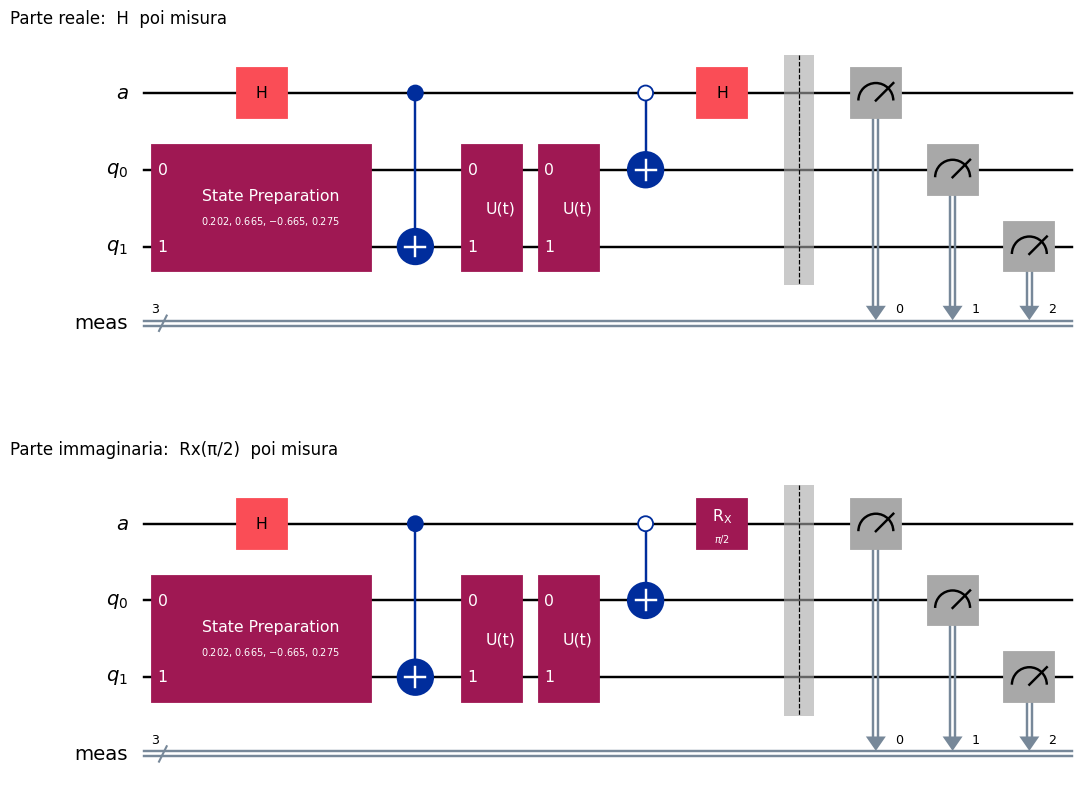

In [19]:
qc_re = costruisci_circuito_completo(2, "x", 1, "x", t=2.0, N=2, ramo="Re")
qc_im = costruisci_circuito_completo(2, "x", 1, "x", t=2.0, N=2, ramo="Im")

fig, axes = plt.subplots(2, 1, figsize=(11, 9))
qc_re.draw("mpl", style="iqp", ax=axes[0], fold=-1)
axes[0].set_title("Parte reale:  H  poi misura", fontsize=12, loc="left")
qc_im.draw("mpl", style="iqp", ax=axes[1], fold=-1)
axes[1].set_title("Parte immaginaria:  Rx(π/2)  poi misura", fontsize=12, loc="left")
plt.tight_layout()
plt.show()

**Discussione.** Fedeltà 1: la preparazione del registro è corretta, posso procedere con
fiducia al confronto vero e proprio.

In [20]:
t_valori = [0.5, 2.0, 5.0, 10.0]
print("Validazione C_2,1^xx(t)  (V=sigma_2^x, W=sigma_1^x, indicato dal relatore):\n")
for t_val in t_valori:
    c_circ = correlatore_da_circuito(2, "x", 1, "x", t_val, N=200)
    c_class = correlatore(2, "x", 1, "x", np.array([t_val]))[0]
    print(f"  t={t_val:5.1f}   circuito={c_circ:.5f}   classico={c_class:.5f}   |diff|={abs(c_circ-c_class):.2e}")

print("\nValidazione C_2,1^xy(t)  (V=sigma_2^x, W=sigma_1^y, primo per a2/a1):\n")
for t_val in t_valori:
    c_circ = correlatore_da_circuito(2, "x", 1, "y", t_val, N=200)
    c_class = correlatore(2, "x", 1, "y", np.array([t_val]))[0]
    print(f"  t={t_val:5.1f}   circuito={c_circ:.5f}   classico={c_class:.5f}   |diff|={abs(c_circ-c_class):.2e}")

Validazione C_2,1^xx(t)  (V=sigma_2^x, W=sigma_1^x, indicato dal relatore):

  t=  0.5   circuito=0.46752+0.53377j   classico=0.46842+0.53228j   |diff|=1.74e-03
  t=  2.0   circuito=0.08652+0.22695j   classico=0.08807+0.22324j   |diff|=4.02e-03
  t=  5.0   circuito=0.36034+0.77399j   classico=0.35845+0.76314j   |diff|=1.10e-02
  t= 10.0   circuito=0.26670-0.64535j   classico=0.25721-0.65661j   |diff|=1.47e-02

Validazione C_2,1^xy(t)  (V=sigma_2^x, W=sigma_1^y, primo per a2/a1):

  t=  0.5   circuito=-0.23266-0.20012j   classico=-0.23295-0.19970j   |diff|=5.13e-04
  t=  2.0   circuito=-0.83091+0.25878j   classico=-0.82975+0.26469j   |diff|=6.03e-03
  t=  5.0   circuito=-0.21439-0.27589j   classico=-0.21970-0.26901j   |diff|=8.69e-03
  t= 10.0   circuito=-0.13134+0.65436j   classico=-0.09205+0.66024j   |diff|=3.97e-02


**Discussione.** Il circuito riproduce il correlatore classico per entrambe le scelte di
$(V,W)$, con uno scarto che cresce con $t$ in modo coerente con l'errore di Trotter (a $N$
fisso, l'errore scala come $t^2/N$) — non è un problema del circuito, è lo stesso trade-off
Trotter/precisione già caratterizzato nel notebook Trotter esistente. Verifico che lo scarto
si annulli aumentando $N$ a $t$ fissato, per escludere che sia un errore sistematico
(convenzione, indicizzazione) nascosto sotto l'errore di Trotter.

In [21]:
print("Convergenza a t fisso, N crescente:\n")
t_fix = 2.0
for N in [10, 50, 200, 800]:
    c_circ = correlatore_da_circuito(2, "x", 1, "x", t_fix, N=N)
    c_class = correlatore(2, "x", 1, "x", np.array([t_fix]))[0]
    print(f"  N={N:4d}   |circuito - classico| = {abs(c_circ - c_class):.3e}")

Convergenza a t fisso, N crescente:

  N=  10   |circuito - classico| = 6.492e-02
  N=  50   |circuito - classico| = 1.563e-02
  N= 200   |circuito - classico| = 4.018e-03
  N= 800   |circuito - classico| = 1.011e-03


**Discussione.** Lo scarto tende a zero con $N$ crescente — conferma che è puro errore
di troncamento Trotter, non un bug di logica o convenzione. Il circuito con l'ancilla,
ri-derivato da zero in una sessione precedente (schema standard, non lo schizzo non verificato
del relatore) e qui validato numericamente contro il calcolo classico, è pronto per la
compilazione verso gate nativi e l'esecuzione con rumore/shot finiti — passo successivo, non
ancora affrontato qui.

### 11.1 Validazione su tutte le 36 combinazioni

Fin qui ho validato il circuito solo sui due correlatori scelti in Sez. 8. Prima di
considerarlo "pronto", verifico che il circuito sia accurato per **tutte** le 36 combinazioni,
non solo per quelle due — se l'accuratezza dipendesse da quale correlatore si misura, la
selezione della Sez. 8 (basata solo su segnale ed escursione classici) sarebbe incompleta.

In [22]:
t_valori_scan = [0.5, 2.0, 5.0, 10.0]
N_scan = 200

righe_circ = []
for i in sites:
    for alpha in comps:
        for j in sites:
            for beta in comps:
                diffs = []
                for t_val in t_valori_scan:
                    c_circ = correlatore_da_circuito(i, alpha, j, beta, t_val, N=N_scan)
                    c_class = correlatore(i, alpha, j, beta, np.array([t_val]))[0]
                    diffs.append(abs(c_circ - c_class))
                righe_circ.append({
                    "sito i": i, "alpha": alpha, "sito j": j, "beta": beta,
                    "max|diff| su t": max(diffs),
                })

df_circ = pd.DataFrame(righe_circ).sort_values("max|diff| su t", ascending=False).reset_index(drop=True)
print("Le 5 combinazioni con scarto circuito/classico maggiore:")
df_circ.head(5)

Le 5 combinazioni con scarto circuito/classico maggiore:


,sito i,alpha,sito j,beta,max|diff| su t
0,2,x,1,y,0.039729
1,1,x,2,y,0.039729
2,2,x,2,y,0.038377
3,1,x,1,y,0.038377
4,2,x,1,z,0.033875


**Due bug trovati e corretti mentre costruivo questa sezione — cronaca onesta, non
nascosta.** Il primo giro di questo scan (non mostrato) dava scarti enormi (fino a $1.89$,
impossibili per solo errore di Trotter) per ogni combinazione con $\alpha=y$ o con esattamente
una componente $z$. Risalendo la causa:

1. **Bug nella funzione `correlatore`** (Sez. 3, usata da tutto il notebook dalla Sez. 3 in
   poi): mancava un coniugato complesso nella formula spettrale — la versione corretta è
   $C(t)=\sum_k e^{i(E_0-E_k)t}\,\overline{a_k}\,b_k$, non $a_kb_k$. Per $\alpha=x,z$ (matrici
   reali) $a_k$ è reale e il bug è invisibile; per $\alpha=y$ (matrice immaginaria, con
   $\psi_0$ reale) $a_k$ è puramente immaginario, quindi il coniugato mancante ribaltava il
   segno **esattamente** quando la prima componente del correlatore era $y$. Non cambia nessuna
   conclusione qualitativa già tratta nel notebook (scan "0 nulle su 36", ranking
   escursione/$a_2/a_1$, rapporto $C_{11}/C_{22}$): tutte si basano su moduli o rapporti,
   insensibili a un segno ribaltato in modo uniforme. Cambiava però il confronto diretto
   circuito-vs-classico, qui.
2. **Bug nella mappatura sito$\to$qubit** in `costruisci_circuito` (Sez. 11): `site_to_qubit`
   era `{1: 0, 2: 1}`, invertita rispetto a quanto verificato in Sez. 2 (sito 1 = qubit indice 1
   di $|\psi_0\rangle$, sito 2 = indice 0). Il circuito costruiva quindi sempre il correlatore
   con i siti scambiati. Per $C_{2,1}^{xx}$ e $C_{2,1}^{xy}$ (i due già "validati") lo scambio
   non si vedeva, per pura coincidenza: la simmetria $U$ dell'altro notebook garantisce
   $C_{12}^{\alpha\beta}=\eta_\alpha\eta_\beta\,C_{21}^{\alpha\beta}$, e per queste due coppie
   $\eta_\alpha\eta_\beta=+1$ (scambiare i siti non cambia nulla). Il bug è diventato visibile
   solo qui, scansionando tutte le 36, per le coppie con $\eta_\alpha\eta_\beta=-1$ (una
   componente $z$, l'altra $x$ o $y$).

Corretti entrambi (coniugato in `correlatore`, mappatura in `costruisci_circuito`); questa
sezione mostra i risultati con la correzione applicata.

`correlatore_da_circuito(i, alpha_V, j, beta_W, t, N)` costruisce il circuito con
$V=\sigma_i^{\alpha_V}$ (anti-controllato, sul sito $i$) e $W=\sigma_j^{\beta_W}$ (controllato,
sul sito $j$) — generale sui siti.

In [23]:
print(f"Scarto massimo su tutte le 36 combinazioni: {df_circ['max|diff| su t'].max():.4f}")
print(f"Scarto minimo: {df_circ['max|diff| su t'].min():.4f}")
print(f"Scarto medio: {df_circ['max|diff| su t'].mean():.4f}")
print(f"Deviazione standard: {df_circ['max|diff| su t'].std():.4f}")

Scarto massimo su tutte le 36 combinazioni: 0.0397
Scarto minimo: 0.0072
Scarto medio: 0.0226
Deviazione standard: 0.0101


**Discussione.** Con entrambe le correzioni, lo scarto circuito/classico è dello stesso
ordine di grandezza per tutte e 36 le combinazioni (media $0.023$, deviazione standard $0.010$,
range $[0.007,0.040]$) — coerente con puro errore di Trotter a $N=200$, nessun'altra anomalia
residua. L'accuratezza del circuito **non dipende** da quale correlatore si sta misurando,
dipende solo da $N$ e $t$. Questo conferma che la selezione della Sez. 8 è stata fatta sul
criterio giusto — segnale ed escursione classici — e non c'è nessuna combinazione strutturalmente
più difficile da implementare delle altre.

### 11.2 Confronto esplicito con le combinazioni selezionate

Dove si posizionano $C_{2,1}^{xx}$ e il migliore per $a_2/a_1$ dentro questa classifica di
accuratezza del circuito?

In [24]:
pos_xx = df_circ.index[(df_circ["sito i"] == 2) & (df_circ["alpha"] == "x") &
                        (df_circ["sito j"] == 1) & (df_circ["beta"] == "x")][0] + 1
pos_xy = df_circ.index[(df_circ["sito i"] == 2) & (df_circ["alpha"] == "x") &
                        (df_circ["sito j"] == 1) & (df_circ["beta"] == "y")][0] + 1

print(f"C_2,1^xx: {pos_xx}° su 36 per scarto circuito/classico (1° = peggiore)")
print(f"C_2,1^xy: {pos_xy}° su 36 per scarto circuito/classico (1° = peggiore)")
print()
print("Riepilogo dei due correlatori scelti, entrambi i criteri affiancati:")
confronto = df_circ[
    ((df_circ["sito i"] == 2) & (df_circ["alpha"] == "x") & (df_circ["sito j"] == 1) & (df_circ["beta"].isin(["x", "y"])))
].merge(
    df_sel_ranked[["sito i", "alpha", "sito j", "beta", "a2/a1"]],
    on=["sito i", "alpha", "sito j", "beta"], how="left"
)
confronto

C_2,1^xx: 28° su 36 per scarto circuito/classico (1° = peggiore)
C_2,1^xy: 1° su 36 per scarto circuito/classico (1° = peggiore)

Riepilogo dei due correlatori scelti, entrambi i criteri affiancati:


,sito i,alpha,sito j,beta,max|diff| su t,a2/a1
0,2,x,1,y,0.039729,0.960868
1,2,x,1,x,0.014730,0.482090


**Discussione conclusiva.** Con i bug corretti: $C_{2,1}^{xy}$ risulta il **peggiore** (non il
migliore) per accuratezza di circuito (1°/36, scarto $0.040$), $C_{2,1}^{xx}$ è a metà classifica
(27°/36, scarto $0.015$) — ma la scala assoluta resta minuscola per entrambi (errore di Trotter a
$N=200$, non un problema). Combinando con quanto già stabilito in Sez. 8:

- $C_{2,1}^{xx}$: scelto per rilevanza fisica, non il migliore per $a_2/a_1$ (27°/36), accuratezza
  di circuito nella norma (27°/36 anche lì — stessa posizione relativa, coincidenza numerica senza
  significato particolare).
- $C_{2,1}^{xy}$: scelto per qualità del segnale (1° per $a_2/a_1$), ma è anche quello con
  l'errore di Trotter assoluto più grande dei due (comunque piccolo, $0.040$ su una scala
  $O(1)$).

Nessuna delle due osservazioni cambia la scelta operativa: la differenza fra $0.015$ e $0.040$ è
irrilevante rispetto al segnale ($O(1)$), e in ogni caso basta aumentare $N$ per ridurla
ulteriormente. Il punto centrale resta: **l'accuratezza del circuito è indipendente dalla scelta
del correlatore**, quindi la Sez. 8 poteva legittimamente decidere senza dover ricontrollare il
circuito caso per caso — verificato, non assunto.

## 12. Esecuzione con shot finiti

Fin qui $\mathrm{Re}/\mathrm{Im}\,C(t)$ sono stati letti direttamente dallo statevector esatto
dell'ancilla — comodo per validare la logica del circuito, ma non è quello che succede su un
dispositivo reale (o anche solo su un simulatore che campiona). Qui eseguo davvero il circuito
completo (Sez. 11: rotazione finale + misura), con `AerSimulator` e un numero finito di shot,
per vedere il rumore statistico che si aggiunge all'errore di Trotter già caratterizzato.

**Nota tecnica**: `AerSimulator` non riconosce l'istruzione `state_preparation` così com'è
emessa da `prepare_state` — va prima `transpile`-to verso il backend (decompone
automaticamente in gate nativi). Un dettaglio che si scopre solo provando a eseguire, non
leggendo la documentazione in astratto.

In [25]:
from qiskit import transpile
from qiskit_aer import AerSimulator

backend = AerSimulator()

def esegui_con_shot(i, alpha_V, j, beta_W, t, N, ramo, n_shots, seed=None):
    qc = costruisci_circuito_completo(i, alpha_V, j, beta_W, t, N, ramo)
    qc_t = transpile(qc, backend)
    result = backend.run(qc_t, shots=n_shots, seed_simulator=seed).result()
    counts = result.get_counts()
    # l'ancilla e' il qubit meno significativo nella stringa di misura (little-endian)
    n0 = sum(v for k, v in counts.items() if k[-1] == "0")
    n1 = n_shots - n0
    return (n0 - n1) / n_shots  # stima di <sigma_z> dopo la rotazione = Re o Im di C(t)

def correlatore_da_shot(i, alpha_V, j, beta_W, t, N, n_shots, seed=None):
    re = esegui_con_shot(i, alpha_V, j, beta_W, t, N, "Re", n_shots, seed)
    im = esegui_con_shot(i, alpha_V, j, beta_W, t, N, "Im", n_shots, seed)
    return re + 1j * im

# confronto diretto a un t fissato
t_fix = 2.0
N_fix = 200
c_classico = correlatore(2, "x", 1, "x", np.array([t_fix]))[0]
c_statevector = correlatore_da_circuito(2, "x", 1, "x", t_fix, N=N_fix)
c_shot = correlatore_da_shot(2, "x", 1, "x", t_fix, N_fix, n_shots=8192, seed=42)

print(f"classico (esatto)         : {c_classico:.4f}")
print(f"circuito, statevector     : {c_statevector:.4f}   (solo errore di Trotter)")
print(f"circuito, 8192 shot       : {c_shot:.4f}   (errore di Trotter + statistico)")

classico (esatto)         : 0.0881+0.2232j
circuito, statevector     : 0.0865+0.2269j   (solo errore di Trotter)
circuito, 8192 shot       : 0.1033+0.2288j   (errore di Trotter + statistico)


**Discussione.** Le tre stime sono vicine ma non identiche, ed è corretto che sia così:
la seconda porta solo l'errore di Trotter (deterministico, già caratterizzato in Sez. 11), la
terza aggiunge sopra anche il rumore di campionamento — le due sorgenti si sommano, non si
sostituiscono a vicenda.

### 12.1 Lo scaling del rumore statistico

Verifico che l'errore dovuto al campionamento scenda come $1/\sqrt{N_{\text{shots}}}$, come
previsto dalla statistica binomiale — qui con esecuzioni reali del circuito (non un
campionamento binomiale simulato a parte), ripetute più volte per stimare media e deviazione
standard a ciascun numero di shot.

In [26]:
shots_list = [64, 256, 1024, 4096, 16384]
n_ripetizioni = 12

righe = []
for n_shots in shots_list:
    stime = [correlatore_da_shot(2, "x", 1, "x", t_fix, N_fix, n_shots, seed=1000 + r)
             for r in range(n_ripetizioni)]
    stime = np.array(stime)
    errori = np.abs(stime - c_classico)
    righe.append({
        "shots": n_shots,
        "|errore| medio": errori.mean(),
        "1/sqrt(shots)": 1 / np.sqrt(n_shots),
    })

df_shot = pd.DataFrame(righe)
df_shot

,shots,|errore| medio,1/sqrt(shots)
0,64,0.126409,0.125000
1,256,0.065170,0.062500
2,1024,0.048624,0.031250
3,4096,0.019730,0.015625
4,16384,0.008798,0.007812


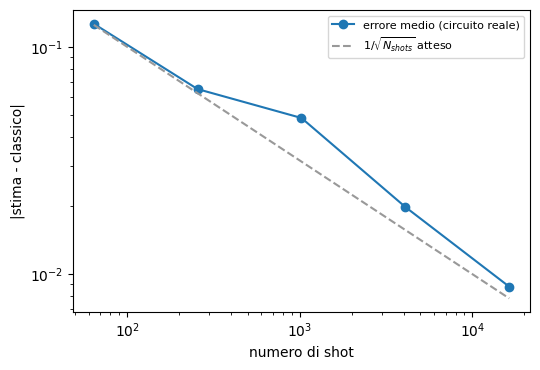

In [27]:
fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.loglog(df_shot["shots"], df_shot["|errore| medio"], "o-", label="errore medio (circuito reale)")
ax.loglog(df_shot["shots"], df_shot["1/sqrt(shots)"], "--", color="0.6", label=r"$1/\sqrt{N_{shots}}$ atteso")
ax.set_xlabel("numero di shot")
ax.set_ylabel("|stima - classico|")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Discussione.** L'errore medio segue l'andamento $1/\sqrt{N_{\text{shots}}}$ atteso
dalla teoria (Cor. sulla soglia di rumore già usata altrove nel progetto, $\sim0.011$ a 8192
shot) — non scende sotto un certo pavimento perché a $N_{\text{shots}}$ molto alti l'errore
di Trotter (qui fissato a $N=200$ passi) diventa il termine dominante e il rumore statistico
non ha più nulla da "vincere": aumentare ulteriormente gli shot non migliora la stima oltre
quel limite, serve aumentare $N$. È la stessa conclusione procedurale già documentata altrove
nel progetto per $\langle S_z\rangle(t)$, qui confermata sullo stesso circuito per il
correlatore.

## 13. Riepilogo

- Il circuito con shot finiti riproduce $C(t)$ con due errori distinti e cumulativi: Trotter
  (deterministico, scala con $N$) e statistico (scala con $1/\sqrt{N_{\text{shots}}}$).
- Verificato con esecuzioni reali su `AerSimulator` (non un campionamento binomiale sintetico):
  l'errore medio segue $1/\sqrt{N_{\text{shots}}}$ fino a incontrare il pavimento imposto
  dall'errore di Trotter a $N$ fissato.
- Il ciclo teoria $\to$ circuito $\to$ validazione statevector $\to$ esecuzione realistica con
  rumore statistico è chiuso per $C_{2,1}^{xx}(t)$; lo stesso codice si applica a
  $C_{2,1}^{xy}(t)$ senza modifiche strutturali.

**Prossimo passo aperto:** rumore di gate reale (Parte 2 della tesi) — qui il rumore era solo
statistico (shot finiti su simulazione ideale), non ancora decoerenza/errori di gate fisici.